# 直近の得点状況・リード状況別の「次の得点」までの待ち時間

`statsbomb_data` 以下の全リーグ・全シーズンの `*_goals_and_red_cards.csv` を対象に、
各時点での「リード/ビハインドの状態」と「直近の得点が自チームによるものかどうか」に応じて、
**そのチーム自身が次に得点するまでの待ち時間**の分布を比較する
（`score_difference.ipynb` と同じヒストグラム仕様）。

以下の5区分でヒストグラムを作る。

1. リードしてるチームかつ直近の得点チーム → そのチームの次の得点までの待ち時間
2. リードしてるチームかつ直近の得点をしていないチーム → そのチームの次の得点までの待ち時間
3. ビハインドしてるチームかつ直近の得点チーム → そのチームの次の得点までの待ち時間
4. ビハインドしてるチームかつ直近の得点をしていないチーム → そのチームの次の得点までの待ち時間
5. 0-0（キックオフ）から最初の得点までの待ち時間
6. 0-0以外の引き分け（同点に戻った直後）かつ直近に得点されたチーム → そのチームの次の得点までの待ち時間
7. 0-0以外の引き分け（同点に戻った直後）かつ直近の得点チーム → そのチームの次の得点までの待ち時間

**注**: 1〜4, 6, 7は「試合内の次の得点イベントまでの時間」ではなく、**その区分に該当するチーム自身が
次に得点するまでの時間**である。単に「次の得点イベントまでの時間」を使うと、区分1と4、
区分2と3が全く同じ値になってしまい、別々のグラフにする意味がなくなるため
（例えば「リードしていて直近に得点したチーム」が次に得点する前に、
「ビハインドしていて直近に得点していないチーム」が先に得点することがあるので、両者の
「次の得点までの時間」は一般に異なる）。

**区分6・7について**: 得点によって同点（1-1、2-2など、0-0を除く）に戻った直後の状態を対象とする。
同点にする得点は必ず直前までビハインドしていたチームによるものなので
（リードしていたチームの得点で同点になることはあり得ない）、区分6「直近に得点されたチーム」＝
直前までリードしていた（＝同点にされた）側、区分7「直近の得点チーム」＝直前までビハインド
していた（＝同点にした）側を指す。


## データ形式・前提

`score_difference.ipynb` と同じ `goals_and_red_cards.csv`（得点イベントの行のみ、`minute + second/60`
を実時間・分として使用）を用いる。

- **区分1〜4の判定タイミング**: 各得点イベントの直後（その得点を反映した後）の得点差で判定する。
  得点直後に同点になった場合（例: 2-1 → 2-2）は、リード/ビハインドのどちらでもないため、
  この4区分からは除外し、代わりに区分6・7で扱う。
- **「そのチームの次の得点」が存在しない場合**（そのままリード/ビハインド/同点の側が試合終了まで
  得点しなかった場合）は、待ち時間が観測できないため除外する（打ち切りデータとして扱わず、
  観測できたケースのみを集計する）。
- **区分5（0-0→最初の得点）**は文字通りキックオフ（0-0）から最初の得点までの時間で、
  1試合につき最大1件（無得点で終わった試合は対象外）。
- **区分6・7（0-0以外の引き分け）**は、得点によって1-1、2-2のように同点に戻った直後の状態を
  対象とする。直近に得点されたチーム（区分6、＝直前までリードしていた側）・
  直近の得点チーム（区分7、＝直前までビハインドしていた側）それぞれについて、
  その後さらに得点したタイミングまでを待ち時間とする。


In [1]:
import glob
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# グラフ内の日本語（タイトル・軸ラベル等）が文字化けしないよう、macOS標準の日本語フォントを指定する。
# （Windows等、別環境で開く場合は "Meiryo" や "Yu Gothic" などお使いの環境にある日本語フォント名に変更してください）
plt.rcParams["font.family"] = "Hiragino Sans"
plt.rcParams["axes.unicode_minus"] = False


## 1. 全リーグ・全シーズンのデータを読み込む

In [2]:
DATA_DIR = "../../statsbomb_data"

csv_paths = sorted(glob.glob(os.path.join(DATA_DIR, "**", "*_goals_and_red_cards.csv"), recursive=True))
print(f"{len(csv_paths)} 件のファイルが見つかりました")

df_all = pd.concat([pd.read_csv(p) for p in csv_paths], ignore_index=True)
print(f"行数: {len(df_all)}, 試合数: {df_all['match_id'].nunique()}")


11 件のファイルが見つかりました
行数: 10048, 試合数: 2461


## 2. 試合ごとに5区分の「次の得点までの待ち時間」を計算する

試合ごとに得点イベントを時刻順に並べ、

- 最初に「0-0 → 最初の得点」の待ち時間を1件記録する。
- その後、各得点イベントの直後の状態（得点差・直近の得点チーム）ごとに、
  リードしているチーム自身の次の得点までの待ち時間と、
  ビハインドしているチーム自身の次の得点までの待ち時間をそれぞれ計算する
  （どちらも、該当チームがそれ以降に得点しなかった場合は記録しない）。


In [3]:
CATEGORY_LABELS = {
    "kickoff": "0-0から最初の得点",
    "leading_scorer": "リード中・直近得点チーム",
    "leading_not_scorer": "リード中・直近得点していないチーム",
    "trailing_scorer": "ビハインド中・直近得点チーム",
    "trailing_not_scorer": "ビハインド中・直近得点していないチーム",
    "tied_was_leading": "同点(0-0以外)・直近に得点されたチーム",
    "tied_was_trailing": "同点(0-0以外)・直近の得点チーム",
}
CATEGORY_ORDER = [
    "kickoff",
    "leading_scorer", "leading_not_scorer",
    "trailing_scorer", "trailing_not_scorer",
    "tied_was_leading", "tied_was_trailing",
]


def build_recent_score_events(df):
    """
    goals_and_red_cards の df（複数リーグ・シーズンを結合したものでも可）から、
    5区分（CATEGORY_ORDER）それぞれについて「該当チーム自身の次の得点までの
    待ち時間」を計算する。
    """
    goal_rows = df[df["red_card"].isna() & df["home_away"].notna()].copy()
    goal_rows["time_min"] = goal_rows["minute"].astype(float) + goal_rows["second"].astype(float) / 60.0
    goal_rows["home_away"] = goal_rows["home_away"].astype(int)

    records = []
    group_cols = ["league_code", "season_name", "match_id"]
    for (league_code, season_name, match_id), g in goal_rows.groupby(group_cols):
        g = g.sort_values("time_min")
        times = g["time_min"].to_numpy()
        sides = g["home_away"].to_numpy()  # 0=home, 1=away
        k = len(times)
        if k == 0:
            continue

        side_times = {0: times[sides == 0], 1: times[sides == 1]}

        def _next_own_goal(side, t):
            future = side_times[side][side_times[side] > t]
            return future[0] if len(future) > 0 else None

        meta = dict(league_code=league_code, season_name=season_name, match_id=match_id)

        # 区分5: 0-0(キックオフ) -> 最初の得点
        records.append({**meta, "category": "kickoff", "waiting_time": times[0] - 0.0})

        home_score = away_score = 0
        for i in range(k):
            t_i, s_i = times[i], sides[i]
            diff_before = home_score - away_score  # この得点が入る直前の得点差
            if s_i == 0:
                home_score += 1
            else:
                away_score += 1
            diff = home_score - away_score

            if diff == 0:
                # 0-0以外の引き分け（区分6・7）。この得点の直前は必ず diff_before != 0
                # （同点だったチームがさらに得点すれば同点のままにはならないため）。
                leader_before = 0 if diff_before > 0 else 1
                trailer_before = 1 - leader_before

                wt_leader = _next_own_goal(leader_before, t_i)
                if wt_leader is not None:
                    records.append({**meta, "category": "tied_was_leading", "waiting_time": wt_leader - t_i})

                wt_trailer = _next_own_goal(trailer_before, t_i)
                if wt_trailer is not None:
                    records.append({**meta, "category": "tied_was_trailing", "waiting_time": wt_trailer - t_i})
                continue

            leader = 0 if diff > 0 else 1
            trailer = 1 - leader

            wt_leader = _next_own_goal(leader, t_i)
            if wt_leader is not None:
                cat = "leading_scorer" if s_i == leader else "leading_not_scorer"
                records.append({**meta, "category": cat, "waiting_time": wt_leader - t_i})

            wt_trailer = _next_own_goal(trailer, t_i)
            if wt_trailer is not None:
                cat = "trailing_scorer" if s_i == trailer else "trailing_not_scorer"
                records.append({**meta, "category": cat, "waiting_time": wt_trailer - t_i})

    return pd.DataFrame(records)


events_df = build_recent_score_events(df_all)
print(f"観測数: {len(events_df)}")
events_df["category"].value_counts().reindex(CATEGORY_ORDER)


観測数: 8500


category
kickoff                2304
leading_scorer         2867
leading_not_scorer      181
trailing_scorer         141
trailing_not_scorer    2161
tied_was_leading        431
tied_was_trailing       415
Name: count, dtype: int64

## 3. ヒストグラムのビンを共通化する

`score_difference.ipynb` と同様、待ち時間（分）のビン幅は5分刻みとし、5区分すべての最大待ち時間
から上限を決めて全グラフで共通のビン境界を使う。最頻値は、このヒストグラムのビンの中で
度数が最大となるビンの中央値として近似的に求める。


In [4]:
BIN_WIDTH = 5  # 分
max_wait = events_df["waiting_time"].max()
BIN_EDGES = np.arange(0, np.ceil(max_wait / BIN_WIDTH) * BIN_WIDTH + BIN_WIDTH, BIN_WIDTH)
print(f"最大待ち時間: {max_wait:.2f}分 -> ビン境界: 0〜{BIN_EDGES[-1]:.0f}分（{BIN_WIDTH}分刻み、{len(BIN_EDGES)-1}ビン）")


最大待ち時間: 94.78分 -> ビン境界: 0〜95分（5分刻み、19ビン）


## 4. 5区分のヒストグラムを1枚の図にまとめて描画・保存する

各パネルに標本数 `n`、平均値（実線）、中央値（破線）、最頻値（点線）を重ねて表示する。
ビン幅・ビン境界は全パネル共通（縦軸のスケールはパネルごとに自動調整）。


保存しました: ./figures/recent_score_histograms.png


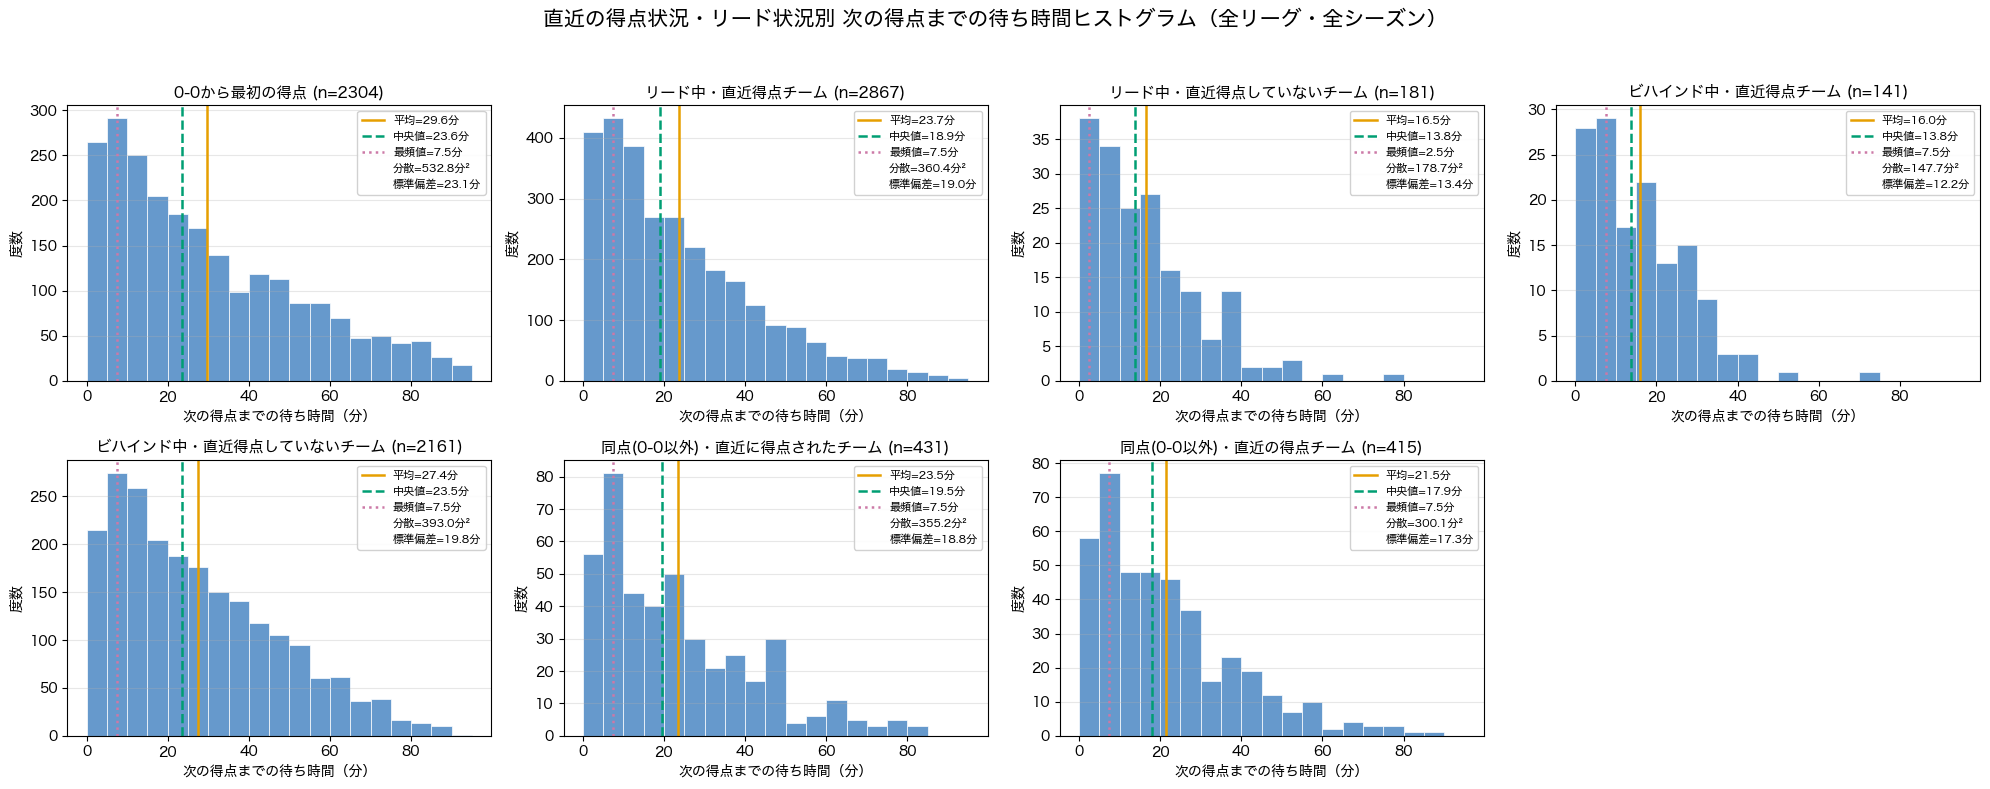

In [5]:
BAR_COLOR = "#6699CC"
MEAN_COLOR = "#E69F00"
MEDIAN_COLOR = "#009E73"
MODE_COLOR = "#CC79A7"


def compute_stats(vals, bin_edges):
    n = len(vals)
    if n == 0:
        return dict(n=0, mean=np.nan, median=np.nan, mode=np.nan, var=np.nan, std=np.nan,
                    counts=np.zeros(len(bin_edges) - 1))
    counts, _ = np.histogram(vals, bins=bin_edges)
    mode_idx = int(np.argmax(counts))
    mode_val = (bin_edges[mode_idx] + bin_edges[mode_idx + 1]) / 2
    return dict(n=n, mean=np.mean(vals), median=np.median(vals), mode=mode_val,
                var=np.var(vals), std=np.std(vals), counts=counts)


def plot_one(ax, vals, title, bin_edges):
    stats = compute_stats(vals, bin_edges)
    ax.bar(bin_edges[:-1], stats["counts"], width=BIN_WIDTH, align="edge",
           color=BAR_COLOR, edgecolor="white", linewidth=0.5)
    if stats["n"] > 0:
        ax.axvline(stats["mean"], color=MEAN_COLOR, linestyle="-", linewidth=1.8,
                    label=f"平均={stats['mean']:.1f}分")
        ax.axvline(stats["median"], color=MEDIAN_COLOR, linestyle="--", linewidth=1.8,
                    label=f"中央値={stats['median']:.1f}分")
        ax.axvline(stats["mode"], color=MODE_COLOR, linestyle=":", linewidth=1.8,
                    label=f"最頻値={stats['mode']:.1f}分")
        var_handle = Line2D([], [], color="none", label=f"分散={stats['var']:.1f}分²")
        std_handle = Line2D([], [], color="none", label=f"標準偏差={stats['std']:.1f}分")
        handles, labels = ax.get_legend_handles_labels()
        handles += [var_handle, std_handle]
        labels += [var_handle.get_label(), std_handle.get_label()]
        ax.legend(handles, labels, fontsize=8, loc="upper right", framealpha=0.9)
    ax.set_title(f"{title} (n={stats['n']})", fontsize=11)
    ax.set_xlabel("次の得点までの待ち時間（分）")
    ax.set_ylabel("度数")
    ax.grid(axis="y", alpha=0.3)
    return stats


fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

all_stats = {}
for i, cat in enumerate(CATEGORY_ORDER):
    vals = events_df.loc[events_df["category"] == cat, "waiting_time"].values
    all_stats[cat] = plot_one(axes[i], vals, CATEGORY_LABELS[cat], BIN_EDGES)

for j in range(len(CATEGORY_ORDER), len(axes)):
    axes[j].axis("off")

fig.suptitle("直近の得点状況・リード状況別 次の得点までの待ち時間ヒストグラム（全リーグ・全シーズン）", fontsize=15)
fig.tight_layout(rect=[0, 0, 1, 0.95])

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/recent_score_histograms.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()


## 5. Kaplan-Meier曲線とログランク検定（打ち切りなし・ヒストグラムと同一標本）

上のヒストグラム（`events_df`）は、区分1〜4・6・7については「その状態にあるチーム自身が
試合終了までに次の得点をした試合」のみを集計しており、次の得点が観測できなかったケース
（本来は打ち切りとして扱うべきケース）はすでに除外されている。

ここでは、この**打ち切りを考慮しない近似**として、`events_df` の `waiting_time` を
そのまま「イベントが発生した時間」として扱い（`event_observed` は全件 True、打ち切りなし）、
区分ごとのKaplan-Meier曲線とログランク検定を行う。

**注意点**
- これは真の意味での打ち切り込みの生存時間解析ではなく、あくまで「次の得点が観測できた
  試合だけ」を使った簡易的な比較である。曲線の下がり方や中央値は、打ち切りを正しく
  組み込んだ場合よりも速く0に近づく（生存時間が短く出る）方向にバイアスがかかりうる。
- 区分1〜4・6・7で真の打ち切り込み解析をしたい場合は、「その状態のまま試合終了まで
  次の得点が起きなかった試合」を打ち切り観測として追加し、`event_observed=False`,
  `waiting_time`＝状態開始から試合終了までの残り時間、としてデータセットを作り直す必要がある。
- ログランク検定は複数区分の一括比較（`multivariate_logrank_test`）と、区分ペアごとの
  比較（`pairwise_logrank_test`）の両方を行う。ペアワイズ比較は多重比較になるため、
  参考として Bonferroni 補正後のp値も併記する。


保存しました: ./figures/recent_score_km_curves.png


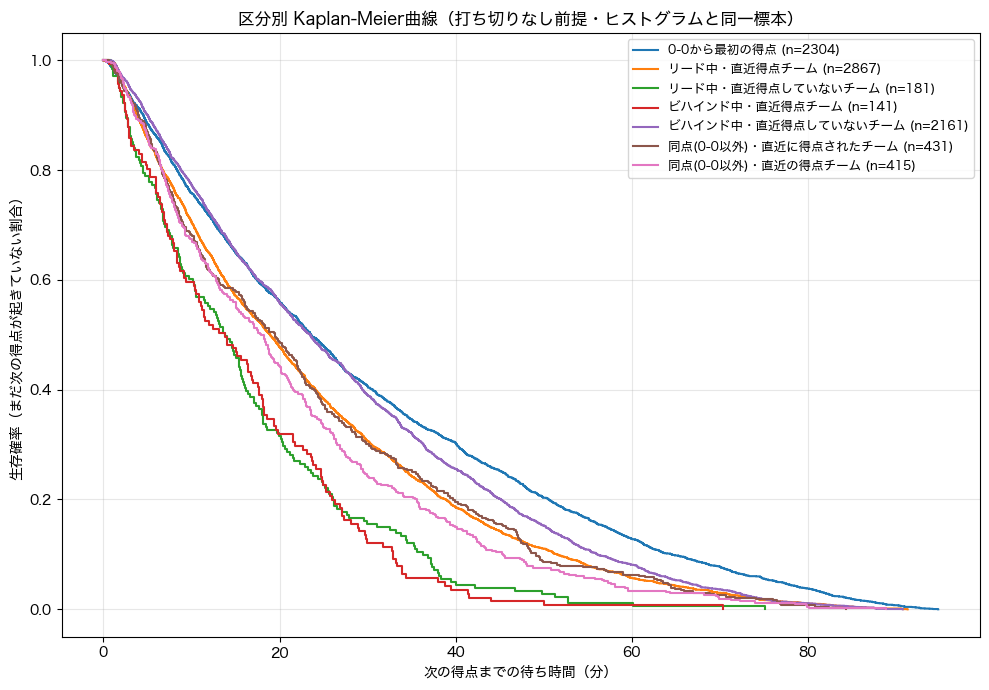

In [6]:
try:
    from lifelines import KaplanMeierFitter
except ModuleNotFoundError:
    # このノートブックのカーネルに lifelines が入っていない場合、自動でインストールする。
    # 同一プロセス内で numpy/matplotlib 等の依存が更新されると壊れることがあるため、
    # インストール後はあえて処理を止め、カーネル再起動を促す。
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "lifelines"])
    raise RuntimeError(
        "lifelines をインストールしました。numpy/matplotlib との整合性のため、"
        "カーネルを再起動してから、このセルより上から再実行してください。"
    )

fig, ax = plt.subplots(figsize=(10, 7))
kmf = KaplanMeierFitter()

for cat in CATEGORY_ORDER:
    vals = events_df.loc[events_df["category"] == cat, "waiting_time"].values
    if len(vals) == 0:
        continue
    # 打ち切りなし前提: event_observed=None -> 全サンプルをイベント発生として扱う
    kmf.fit(durations=vals, event_observed=None, label=f"{CATEGORY_LABELS[cat]} (n={len(vals)})")
    kmf.plot_survival_function(ax=ax, ci_show=False)

ax.set_xlabel("次の得点までの待ち時間（分）")
ax.set_ylabel("生存確率（まだ次の得点が起きていない割合）")
ax.set_title("区分別 Kaplan-Meier曲線（打ち切りなし前提・ヒストグラムと同一標本）")
ax.grid(alpha=0.3)
ax.legend(fontsize=9, loc="upper right")
fig.tight_layout()

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/recent_score_km_curves.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()


In [7]:
from lifelines.statistics import multivariate_logrank_test, pairwise_logrank_test

# 全区分を一括で比較するログランク検定（打ち切りなし前提）
overall_result = multivariate_logrank_test(
    event_durations=events_df["waiting_time"],
    groups=events_df["category"],
)
print("=== 全区分一括のログランク検定 ===")
overall_result.print_summary()

# 区分間のペアワイズ比較
pairwise_result = pairwise_logrank_test(
    event_durations=events_df["waiting_time"],
    groups=events_df["category"],
)

pairwise_summary = pairwise_result.summary.copy()
pairwise_summary.index = pairwise_summary.index.set_levels(
    [
        pairwise_summary.index.levels[0].map(CATEGORY_LABELS),
        pairwise_summary.index.levels[1].map(CATEGORY_LABELS),
    ]
)
n_comparisons = len(pairwise_summary)
pairwise_summary["p_bonferroni"] = (pairwise_summary["p"] * n_comparisons).clip(upper=1.0)
pairwise_summary = pairwise_summary.sort_values("p")

def stars(p):
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.10:
        return "*"
    else:
        return ""

# p値そのものに有意水準の星を付けた文字列に置き換える（例: 2.352009e-26***）
pairwise_summary["p"] = pairwise_summary["p"].apply(lambda v: f"{v:.6e}{stars(v)}")
pairwise_summary["p_bonferroni"] = pairwise_summary["p_bonferroni"].apply(lambda v: f"{v:.6e}{stars(v)}")

print(f"\n=== 区分間のペアワイズ・ログランク検定（p値昇順、比較数={n_comparisons}） ===")
print("有意水準: * p<0.10, ** p<0.05, *** p<0.01")
pairwise_summary


=== 全区分一括のログランク検定 ===



=== 区分間のペアワイズ・ログランク検定（p値昇順、比較数=21） ===
有意水準: * p<0.10, ** p<0.05, *** p<0.01


test_statistic                p  \
0-0から最初の得点            リード中・直近得点チーム               112.829079  2.352009e-26***   
                      リード中・直近得点していないチーム           90.543540  1.809509e-21***   
                      ビハインド中・直近得点チーム              79.976322  3.789236e-19***   
リード中・直近得点していないチーム     ビハインド中・直近得点していないチーム         77.231724  1.520318e-18***   
ビハインド中・直近得点していないチーム   ビハインド中・直近得点チーム              73.158167  1.196654e-17***   
0-0から最初の得点            同点(0-0以外)・直近の得点チーム          59.620202  1.150481e-14***   
                      同点(0-0以外)・直近に得点されたチーム       35.686367  2.317804e-09***   
リード中・直近得点していないチーム     リード中・直近得点チーム                35.120151  3.099765e-09***   
リード中・直近得点チーム          ビハインド中・直近得点していないチーム         34.346995  4.611119e-09***   
                      ビハインド中・直近得点チーム              33.934979  5.698494e-09***   
同点(0-0以外)・直近の得点チーム    ビハインド中・直近得点していないチーム         32.689578  1.081154e-08***   
同点(0-0以外)・直近に得点されたチーム ビハインド中・直近得点チーム              25.392324  4.677758e-07***   
リード中・直近得点していないチーム     同点(0-0以外)・直近に得点されたチーム       25.137748  5.337771e-07***   
0-0から最初の得点            ビハインド中・直近得点していないチーム         24.981596  5.788019e-07***   
同点(0-0以外)・直近の得点チーム    ビハインド中・直近得点チーム              15.506217  8.223436e-05***   
リード中・直近得点していないチーム     同点(0-0以外)・直近の得点チーム          14.349859  1.517911e-04***   
同点(0-0以外)・直近に得点されたチーム ビハインド中・直近得点していないチーム         13.119910  2.921741e-04***   
リード中・直近得点チーム          同点(0-0以外)・直近の得点チーム           5.360880   2.059338e-02**   
同点(0-0以外)・直近に得点されたチーム 同点(0-0以外)・直近の得点チーム           2.419870     1.198049e-01   
リード中・直近得点していないチーム     ビハインド中・直近得点チーム               0.256213     6.127336e-01   
リード中・直近得点チーム          同点(0-0以外)・直近に得点されたチーム        0.110040     7.400989e-01   

                                              -log2(p)     p_bonferroni  
0-0から最初の得点            リード中・直近得点チーム           85.136237  4.939220e-25***  
                      リード中・直近得点していないチーム      68.904892  3.799968e-20***  
                      ビハインド中・直近得点チーム         61.194727  7.957395e-18***  
リード中・直近得点していないチーム     ビハインド中・直近得点していないチーム    59.190332  3.192668e-17***  
ビハインド中・直近得点していないチーム   ビハインド中・直近得点チーム         56.213772  2.512972e-16***  
0-0から最初の得点            同点(0-0以外)・直近の得点チーム     46.304756  2.416010e-13***  
                      同点(0-0以外)・直近に得点されたチーム  28.684594  4.867389e-08***  
リード中・直近得点していないチーム     リード中・直近得点チーム           28.265194  6.509507e-08***  
リード中・直近得点チーム          ビハインド中・直近得点していないチーム    27.692236  9.683350e-08***  
                      ビハインド中・直近得点チーム         27.386772  1.196684e-07***  
同点(0-0以外)・直近の得点チーム    ビハインド中・直近得点していないチーム    26.462853  2.270423e-07***  
同点(0-0以外)・直近に得点されたチーム ビハインド中・直近得点チーム         21.027679  9.823293e-06***  
リード中・直近得点していないチーム     同点(0-0以外)・直近に得点されたチーム  20.837259  1.120932e-05***  
0-0から最初の得点            ビハインド中・直近得点していないチーム    20.720427  1.215484e-05***  
同点(0-0以外)・直近の得点チーム    ビハインド中・直近得点チーム         13.569899  1.726922e-03***  
リード中・直近得点していないチーム     同点(0-0以外)・直近の得点チーム     12.685625  3.187613e-03***  
同点(0-0以外)・直近に得点されたチーム ビハインド中・直近得点していないチーム    11.740884  6.135656e-03***  
リード中・直近得点チーム          同点(0-0以外)・直近の得点チーム      5.601676     4.324609e-01  
同点(0-0以外)・直近に得点されたチーム 同点(0-0以外)・直近の得点チーム      3.061242     1.000000e+00  
リード中・直近得点していないチーム     ビハインド中・直近得点チーム          0.706668     1.000000e+00  
リード中・直近得点チーム          同点(0-0以外)・直近に得点されたチーム   0.434210     1.000000e+00